# Experiments Notebook — *Feature Relevancy, Necessity and Usefulness*

This notebook is a guide to the **entire** experimentation from the corrected, tested
engine in [`experiments.py`](experiments.py):

1. Feature usefulness qualitative analysis;
2. Comparison against SHAP, permutation importance and LIME;
3. Runtime analysis;
4. Binning strategy sensitivity (uniform / quantile / kmeans).

The heavy code lives in the module (so it stays tested and reusable); the cells below
are a thin, readable layer that calls it and shows each table/figure inline.

**How to use:** edit `DATASET` / `N_MODELS` in the setup cell, then *Run All*.
Bike Sharing runs fully offline; California and Adult download their public datasets
on first use. Everything is seeded, so re-runs are identical.

In [ ]:
# Make the engine importable whether this notebook sits in extensions/ or the repo root.
import os, sys, warnings
warnings.filterwarnings('ignore')
for _cand in (os.getcwd(), os.path.join(os.getcwd(), 'extensions')):
    if os.path.exists(os.path.join(_cand, 'experiments.py')):
        sys.path.insert(0, _cand); break
import experiments as ux
from IPython.display import Image, display

# ---- experiment settings (edit these) ----
DATASET    = 'bike_sharing'   # 'california' | 'bike_sharing' | 'adult_income'
N_MODELS   = 10               # trees per configuration (the paper uses 20)
RESULTS    = 'results'        # where CSVs and figures are written
os.makedirs(RESULTS, exist_ok=True)

ux.set_all_seeds(42)
ux.set_plot_style()
cfg = ux.Config(n_models=N_MODELS)

METHODS = ('usefulness', 'permutation', 'shap', 'lime')

TAG = os.path.join(RESULTS, DATASET)   # output filename prefix for this dataset
def show(path_no_ext, width=None):     # display a saved figure inline
    display(Image(filename=path_no_ext + '.png', width=width))

print(f'dataset={DATASET}  n_models={N_MODELS}  methods={METHODS}')

### Sanity check — the tree algebra

The corrected core still reproduces every known-answer count from the paper's test cell
(model counting, negation, conjunction, conditioning, and the domain-minimum fix).

In [21]:
ux.run_tree_tests()

run_tree_tests: all assertions passed


### A fixed bug worth seeing: the `season` domain

The original paper declared the Bike features `season` / `weathersit` over the domain
`(0, 1)` / `(0, 4)`, but their real values are **1–4**. With the wrong domain,
`season`'s usefulness score collapses to **0** (last place).
The fix (`correct_categorical_domains=True`, the default) restores it.
*(Only meaningful for Bike Sharing.)*

In [24]:
if DATASET == 'bike_sharing':
    for corrected in (False, True):
        b = ux.train_tree('bike_sharing', bins=6, strategy='quantile', seed=420,
                          leaves=600, correct_categorical_domains=corrected)
        sc = dict(zip(b.features, ux.usefulness_scores(b.clf, b.domains, b.features)))
        rank = [f for f, _ in sorted(sc.items(), key=lambda t: -t[1])]
        label = 'corrected (1..4)' if corrected else 'original (0,1)/(0,4)'
        print(f'{label:22s} season score = {sc["season"]:.3e}   rank = {rank.index("season")+1}/{len(rank)}')
else:
    print('Skip: this demo is specific to Bike Sharing.')

original (0,1)/(0,4)   season score = 0.000e+00   rank = 12/12
corrected (1..4)       season score = 1.114e+07   rank = 3/12


## 1. Feature usefulness qualitative analysis

Train `N_MODELS` trees per bin count and aggregate each feature's usefulness score
(median bar, Q1–Q3 whiskers) together with the mean model accuracy.

In [ ]:
scores = ux.run_score_experiment(DATASET, cfg, strategy='uniform')
ux.plot_scores(scores, DATASET, f'{TAG}_usefulness_scores')
for _bins in sorted(scores['per_bins']):
    show(f'{TAG}_usefulness_scores_{_bins}bins')
scores['table'].head(12)   # per-feature quartiles (tidy table, also saved to CSV)

## 2. Comparison with other importance methods

Compute every method on the **same** trees and compare the *rankings* they induce:
a normalized-importance heatmap, pairwise rank correlation, Rank-Biased Overlap
(top-weighted rank similarity), and top-k overlap with the usefulness ranking.

In [ ]:
comp = ux.run_comparison_experiment(DATASET, cfg, bins=6, methods=METHODS, n_models=N_MODELS)
for _name, _fn in [('importance_heatmap',      ux.plot_method_importance_heatmap),
                   ('rank_correlation',        ux.plot_rank_correlation_heatmap),
                   ('rank_biased_overlap',     ux.plot_rank_biased_overlap_heatmap),
                   ('topk_overlap',            ux.plot_topk_intersection)]:
    _fn(comp, f'{TAG}_{_name}')
    show(f'{TAG}_{_name}')
print('Mean Spearman rank correlation with usefulness:')
display(comp['corr_spearman']['usefulness'].drop('usefulness').sort_values(ascending=False).round(3))
print(f'Mean Rank-Biased Overlap with usefulness (p={cfg.rbo_p}):')
display(comp['rbo']['usefulness'].drop('usefulness').sort_values(ascending=False).round(3))

In [ ]:
# Score distribution table: shows the staircase property of the usefulness score
# (discrete levels vs continuous near-zero values from sampling-based methods)
comp['mean_importance'].to_latex(f'{TAG}_mean_importance.tex', float_format='%.3f', booktabs=True)
print('Mean normalized importance (saved to LaTeX):')
display(comp['mean_importance'].round(3))

## 3. Runtime analysis

How the usefulness algorithm scales with the number of bins (via `perf_counter`),
the wall-clock cost of every importance method on the same model, and how each
method's runtime scales with tree size (one line per method, repeated 10x per
size to show the timing variance as a mean ± std band and a coefficient-of-
variation bar chart).

In [ ]:
scaling = ux.scaling_experiment(DATASET, cfg, strategy='uniform')
ux.plot_scaling(scaling, DATASET, f'{TAG}_scaling')
show(f'{TAG}_scaling')

In [ ]:
# runtime vs tree size, every method, repeated for variance (mean ± std band + CV bars)
method_scaling = ux.method_scaling_experiment(DATASET, cfg, strategy='uniform', methods=METHODS)
ux.plot_method_scaling(method_scaling, DATASET, f'{TAG}_method_scaling')
show(f'{TAG}_method_scaling_runtime')
show(f'{TAG}_method_scaling_variance')

# focused head-to-head: usefulness vs SHAP (both structure-aware methods)
uf_shap = method_scaling[method_scaling['method'].isin(['usefulness', 'shap'])]
ux.plot_method_scaling(uf_shap, DATASET, f'{TAG}_method_scaling_usefulness_vs_shap')
show(f'{TAG}_method_scaling_usefulness_vs_shap_runtime')
show(f'{TAG}_method_scaling_usefulness_vs_shap_variance')

### A fairer performance picture

The raw runtime bar is a bit unfair to the usefulness score: the prototype spent
most of its time in `copy.deepcopy`, not the algorithm — a copy-free scorer is
~5x faster with *identical* results.

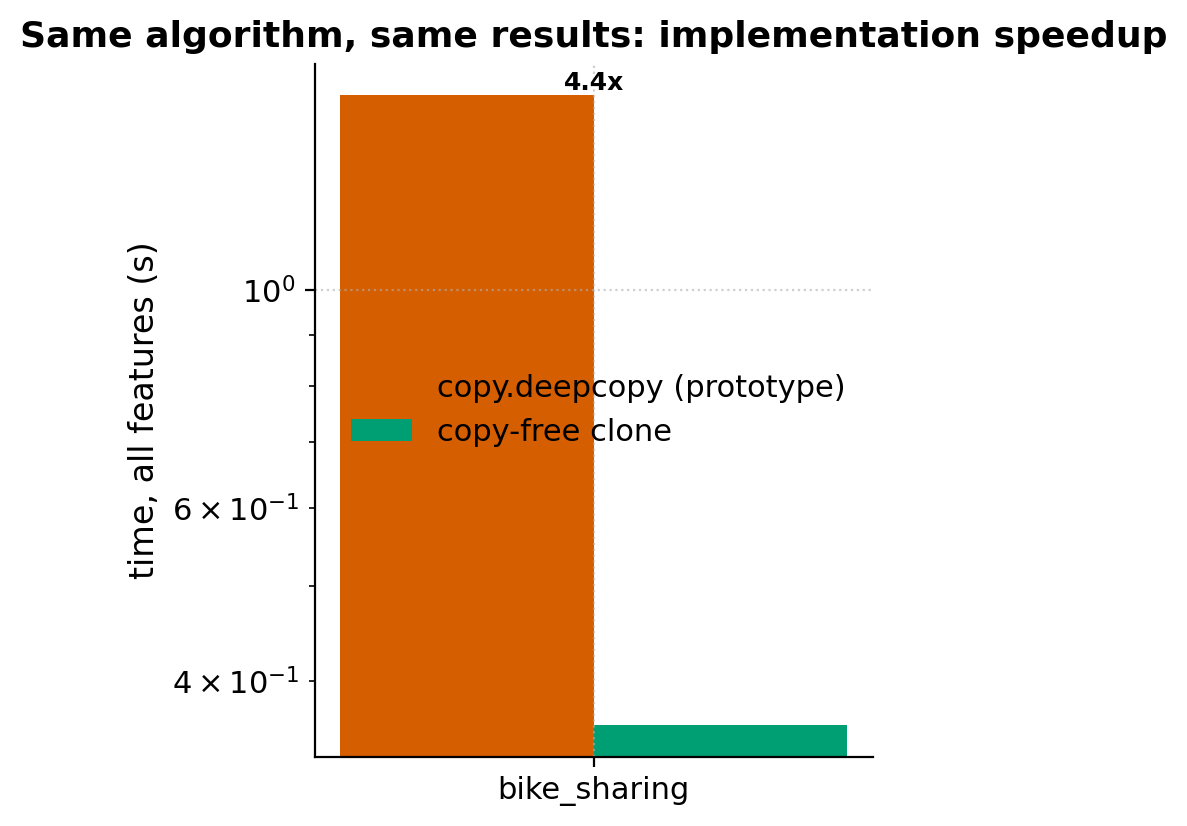

 deepcopy_s  clone_s  speedup
      1.581    0.361     4.38


In [28]:
import pandas as pd
# (a) implementation speedup (same algorithm, identical results)
speedup = pd.DataFrame([ux.profile_scorer_speedup(model)])
ux.plot_scorer_speedup(speedup, f'{TAG}_scorer_speedup'); show(f'{TAG}_scorer_speedup')
print(speedup[['deepcopy_s', 'clone_s', 'speedup']].round(3).to_string(index=False))

## 4. Binning-strategy sensitivity

Re-run under `uniform` / `quantile` / `kmeans` discretisation and measure accuracy,
and how much the induced ranking moves -- both across strategies (fixed bins) and
across bin counts (fixed strategy) -- using Spearman and Rank-Biased Overlap.

In [ ]:
binning = ux.run_binning_experiment(DATASET, cfg, n_models=N_MODELS)
ux.plot_binning_sensitivity(binning, DATASET, f'{TAG}_binning')
show(f'{TAG}_binning_accuracy')
show(f'{TAG}_binning_stability')
show(f'{TAG}_binning_stability_rbo')
show(f'{TAG}_binning_bins_stability')
show(f'{TAG}_binning_bins_stability_rbo')
binning['summary'].round(3)

## Reproduce all three datasets

Set `DATASET` to `california` or `adult_income` above and *Run All*, or run everything
headless with the driver (identical results, no notebook state to worry about):

```bash
python experiments_driver.py --datasets california bike_sharing adult_income --n-models 20
```